<a href="https://colab.research.google.com/github/Catalina-Raposo/challenge2_telecomX_parte1/blob/main/Challenge2_TelecomX_LATAM_Parte_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TelecomX_LATAM - Parte 1**

# FASE 1: EXTRACCIÓN Y PREPARACIÓN

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 FASE 2: TRANSFORMACIÓN

## 2.1 Desanidamiento de datos
Al revisar la estructura inicial, observamos que la información detallada de los clientes, sus servicios telefónicos, de internet y detalles de cuenta se encuentran en formato de diccionarios anidados dentro de 4 columnas principales.

Para poder manipular y analizar cada variable de forma independiente, procederemos a extraer y aplanar estas columnas, uniéndolas nuevamente con el `customerID` y la variable objetivo `Churn`.

In [ ]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df_flat = pd.concat([df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)

df_flat.info()
df_flat.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


## 2.2 Limpieza, Estandarización y Creación de Variables
Una vez aplanado el conjunto de datos, realizaremos los siguientes ajustes necesarios:

1.  **Filtrado de datos:** Eliminaremos los registros donde la variable objetivo `Churn` está vacía, ya que no nos sirven para analizar la evasión.
2.  **Corrección de tipos:** La columna `Charges.Total` está catalogada como texto (string). La convertiremos a formato numérico, eliminando los valores que no puedan convertirse.
3.  **Creación de variables:** Crearemos la métrica `Cuentas_Diarias` (cargos mensuales divididos entre 30) para un análisis más granular.
4.  **Traducción:** Renombraremos las columnas al español para facilitar la lectura del informe final.

In [ ]:
df_clean = df_flat[df_flat['Churn'] != ''].copy()
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')
df_clean = df_clean.dropna(subset=['Charges.Total'])

df_clean['Cuentas_Diarias'] = round(df_clean['Charges.Monthly'] / 30, 2)
columnas_esp = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales'
}

df_clean.rename(columns=columnas_esp, inplace=True)

print(f"Total de registros listos para el análisis: {len(df_clean)}")
df_clean.info()

Total de registros listos para el análisis: 7032
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7032 non-null   object 
 1   Evasion                  7032 non-null   object 
 2   Genero                   7032 non-null   object 
 3   Adulto_Mayor             7032 non-null   int64  
 4   Pareja                   7032 non-null   object 
 5   Dependientes             7032 non-null   object 
 6   Meses_Contrato           7032 non-null   int64  
 7   Servicio_Telefonico      7032 non-null   object 
 8   Multiples_Lineas         7032 non-null   object 
 9   Servicio_Internet        7032 non-null   object 
 10  Seguridad_Online         7032 non-null   object 
 11  Respaldo_Online          7032 non-null   object 
 12  Proteccion_Dispositivo   7032 non-null   object 
 13  Soporte_Tecnico          7032 non-

# 📊 FASE 3: CARGA Y ANÁLISIS

## 3.1 Análisis Descriptivo y Distribución de Evasión
En esta etapa exploraremos el comportamiento general de nuestros datos.
Primero, observaremos las estadísticas descriptivas de nuestras variables numéricas (como promedios y valores máximos).
Luego, visualizaremos la variable más importante del proyecto: **Evasion (Churn)**, para entender exactamente qué porcentaje de nuestros clientes nos han abandonado.

,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30,2.16
std,24.55,30.09,2266.77,1.00
min,1.00,18.25,18.80,0.61
25%,9.00,35.59,401.45,1.19
50%,29.00,70.35,1397.48,2.34
75%,55.00,89.86,3794.74,2.99
max,72.00,118.75,8684.80,3.96


/tmp/ipykernel_235/1058258129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='Evasion', palette=colores)


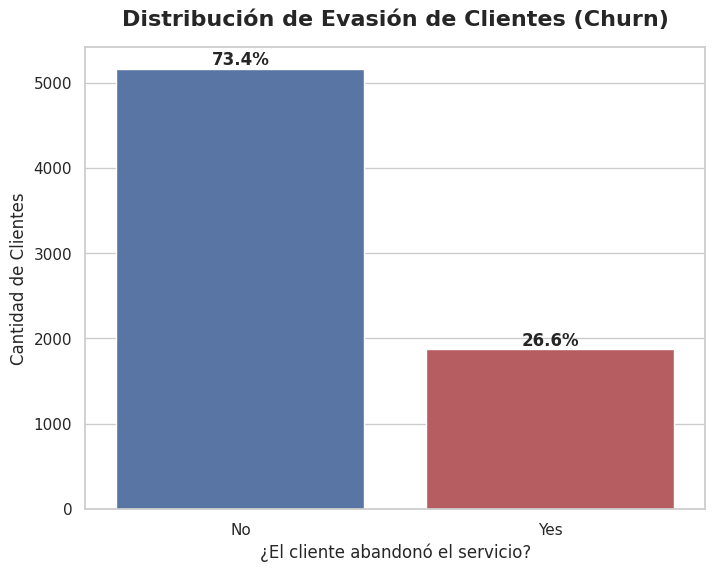

In [ ]:
estadisticas = df_clean[['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].describe().round(2)
display(estadisticas)

plt.figure(figsize=(8, 6))
colores = ['#4C72B0', '#C44E52']
ax = sns.countplot(data=df_clean, x='Evasion', palette=colores)
total = len(df_clean)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('¿El cliente abandonó el servicio?', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.show()

## 3.2 Análisis de Evasión por Variables Categóricas Clave
Sabiendo que la tasa global de abandono es del 26.6%, necesitamos identificar qué perfiles de clientes son más propensos a irse.
Analizaremos cuatro factores fundamentales: el tipo de contrato, el servicio de internet que usan, su método de pago y si pertenecen a la demografía de adultos mayores.

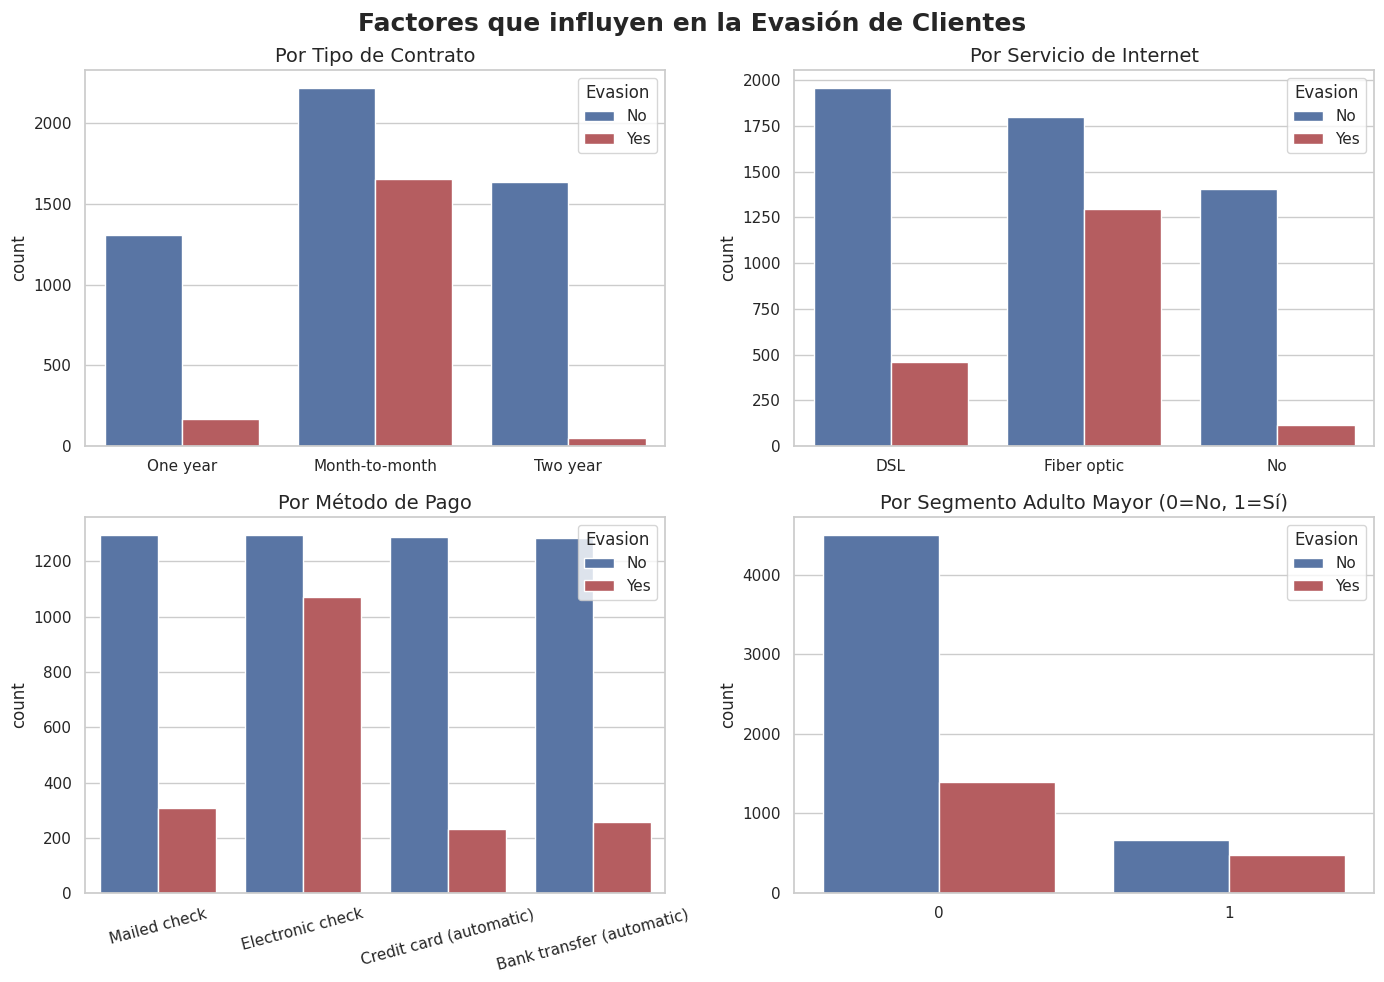

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Factores que influyen en la Evasión de Clientes', fontsize=18, fontweight='bold')
colores_churn = {'No': '#4C72B0', 'Yes': '#C44E52'}

sns.countplot(data=df_clean, x='Tipo_Contrato', hue='Evasion', palette=colores_churn, ax=axes[0, 0])
axes[0, 0].set_title('Por Tipo de Contrato', fontsize=14)
axes[0, 0].set_xlabel('')

sns.countplot(data=df_clean, x='Servicio_Internet', hue='Evasion', palette=colores_churn, ax=axes[0, 1])
axes[0, 1].set_title('Por Servicio de Internet', fontsize=14)
axes[0, 1].set_xlabel('')

sns.countplot(data=df_clean, x='Metodo_Pago', hue='Evasion', palette=colores_churn, ax=axes[1, 0])
axes[1, 0].set_title('Por Método de Pago', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].set_xlabel('')

sns.countplot(data=df_clean, x='Adulto_Mayor', hue='Evasion', palette=colores_churn, ax=axes[1, 1])
axes[1, 1].set_title('Por Segmento Adulto Mayor (0=No, 1=Sí)', fontsize=14)
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 3.3 Análisis de Evasión por Variables Numéricas
Ahora analizaremos cómo el factor tiempo (antigüedad del cliente) y el factor dinero (facturación) afectan la decisión de abandonar el servicio.
Utilizaremos diagramas de caja para visualizar la distribución de estas variables continuas y comparar las medianas entre los clientes retenidos y los fugados.

/tmp/ipykernel_235/703933408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Evasion', y='Meses_Contrato', palette=colores_churn, ax=axes[0])
/tmp/ipykernel_235/703933408.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Evasion', y='Cargos_Mensuales', palette=colores_churn, ax=axes[1])
/tmp/ipykernel_235/703933408.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Evasion', y='Cuentas_Diarias', palette=colores_churn, ax=axes[2])


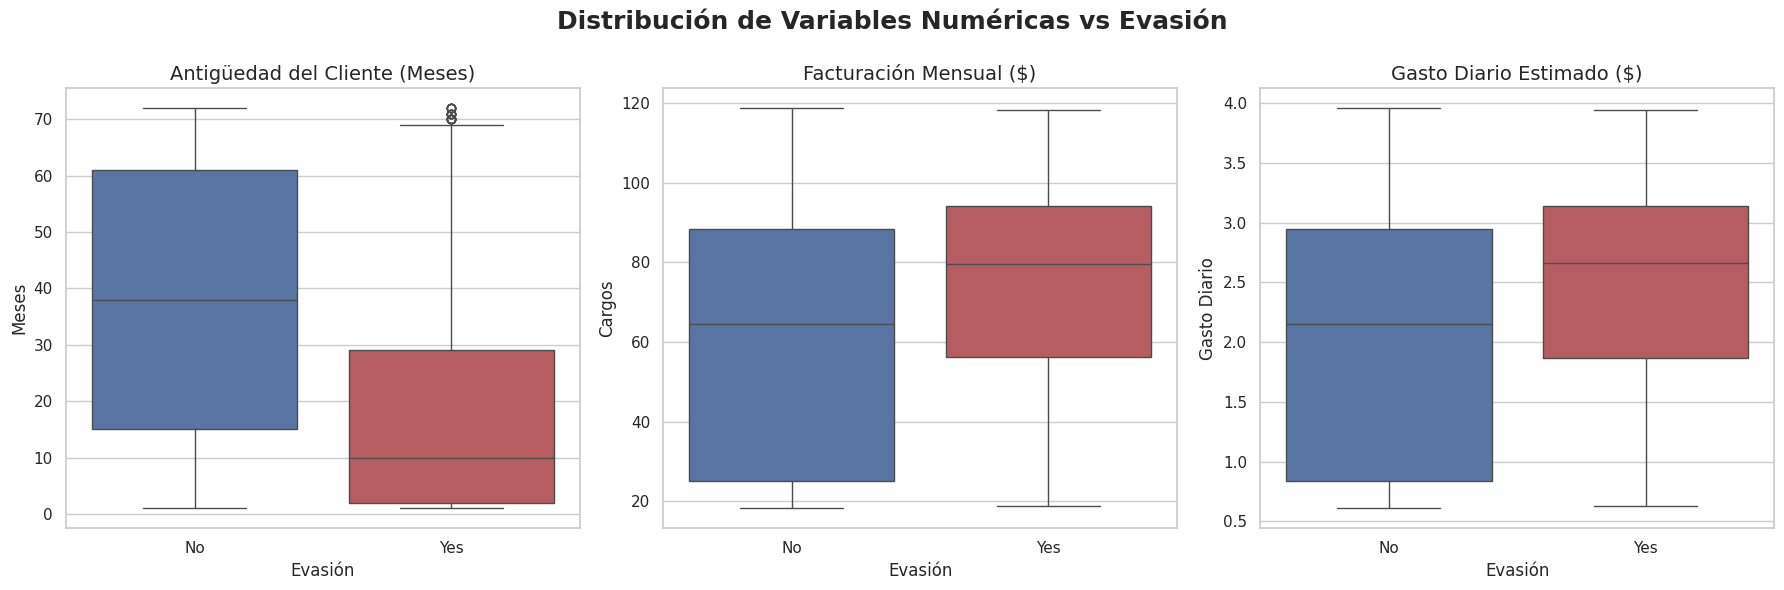

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Variables Numéricas vs Evasión', fontsize=18, fontweight='bold')

sns.boxplot(data=df_clean, x='Evasion', y='Meses_Contrato', palette=colores_churn, ax=axes[0])
axes[0].set_title('Antigüedad del Cliente (Meses)', fontsize=14)
axes[0].set_xlabel('Evasión')
axes[0].set_ylabel('Meses')

sns.boxplot(data=df_clean, x='Evasion', y='Cargos_Mensuales', palette=colores_churn, ax=axes[1])
axes[1].set_title('Facturación Mensual ($)', fontsize=14)
axes[1].set_xlabel('Evasión')
axes[1].set_ylabel('Cargos')

sns.boxplot(data=df_clean, x='Evasion', y='Cuentas_Diarias', palette=colores_churn, ax=axes[2])
axes[2].set_title('Gasto Diario Estimado ($)', fontsize=14)
axes[2].set_xlabel('Evasión')
axes[2].set_ylabel('Gasto Diario')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# 🌟 EXTRA: Análisis de Correlación
Como paso adicional, exploraremos la relación matemática entre nuestras variables numéricas y la probabilidad de evasión.
Para lograr esto, primero binarizaremos la columna `Evasion` (convirtiendo "Yes" a 1 y "No" a 0). Luego, calcularemos la matriz de correlación de Pearson y la visualizaremos usando un mapa de calor.

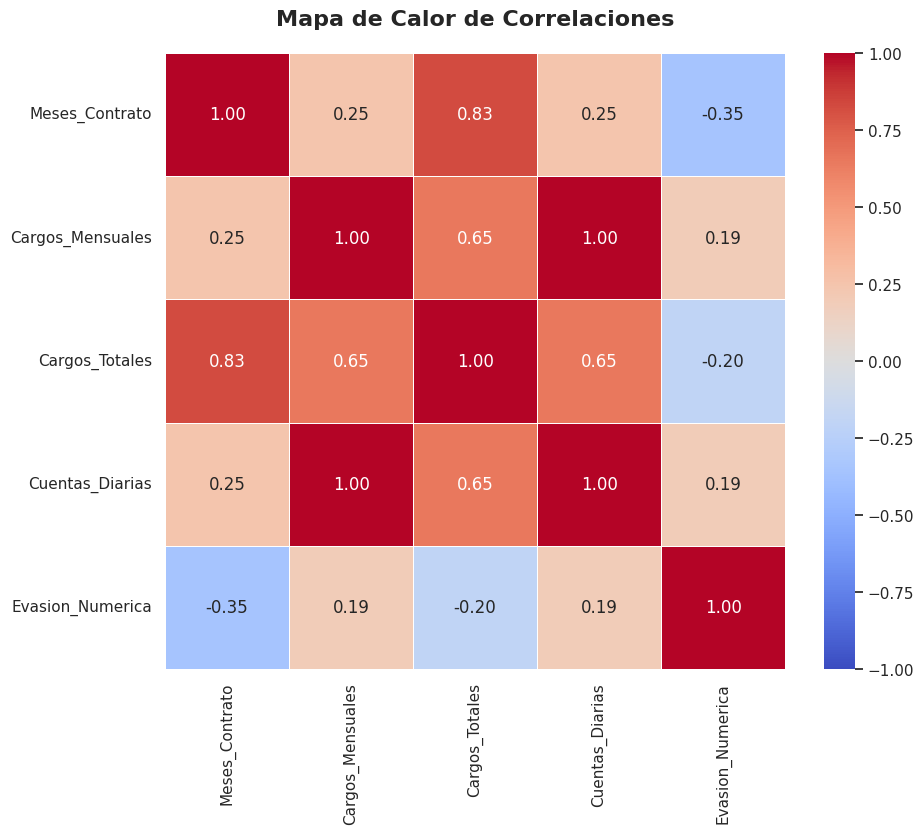

In [ ]:
df_corr = df_clean.copy()
df_corr['Evasion_Numerica'] = df_corr['Evasion'].map({'Yes': 1, 'No': 0})

columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion_Numerica']
matriz_correlacion = df_corr[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=16, fontweight='bold', pad=20)
plt.show()

# 📝 INFORME FINAL: Conclusiones y Recomendaciones

## 1. Resumen del Proyecto
El objetivo de este análisis fue identificar los factores clave que impulsan la evasión de clientes en Telecom X, partiendo de una base de datos de más de 7,000 registros. Se realizó un proceso de ETL (Extracción, Transformación y Limpieza), aplanando estructuras anidadas (JSON) y preparando los datos para un Análisis Exploratorio (EDA).

## 2. Principales Hallazgos (Insights)
A partir de las visualizaciones y el análisis de correlación, identificamos los siguientes patrones:
* **Tasa de Abandono Crítica:** El 26.6 de la base de clientes actual ha cancelado su servicio.
* **El Peligro del Corto Plazo:** Los clientes con contratos mensuales representan la inmensa mayoría de las cancelaciones. La retención mejora drásticamente en contratos de uno o dos años.
* **Problemas con la Fibra Óptica:** Paradójicamente, los usuarios con internet de fibra óptica (usualmente un servicio premium) tienen una tasa de abandono significativamente mayor que los de ADSL.
* **Vulnerabilidad Temprana:** La mediana de antigüedad de los clientes que abandonan es de apenas 10 meses Si un cliente supera su primer año, es muy probable que se quede a largo plazo (correlación negativa de -0.35 entre antigüedad y churn).
* **Sensibilidad al Precio:** Facturaciones más altas y métodos de pago como el cheque electrónico están ligeramente asociados a una mayor probabilidad de fuga.

## 3. Recomendaciones Estratégicas para Telecom X
Basados en los datos, sugerimos las siguientes acciones para reducir la evasión:
1. **Incentivar Contratos a Largo Plazo:** Crear campañas atractivas (ej. descuentos en los primeros meses o instalación gratuita) para que los clientes actuales de pago mensual migren a contratos anuales.
2. **Auditoría de la Fibra Óptica:** Investigar urgentemente por qué los clientes de fibra óptica se están yendo. Podría tratarse de problemas técnicos prolongados, fallas en la velocidad prometida o un precio no competitivo frente a la competencia.
3. **Programa de Fidelización Temprana:** Implementar estrategias de seguimiento al cliente (llamadas de seguimiento, bonos, soporte técnico proactivo) durante los primeros 10 meses críticos de servicio.